### Lorenz attractor - Dataset

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/lorenze_attractor.csv')
df.head()

,Unnamed: 0,X,Y,Z,U,t
0,0,0.000000,1.000000,20.000000,0.0000,0.00000
1,1,0.002497,0.999753,19.986685,0.0005,0.00025
2,2,0.004986,0.999510,19.973366,0.0010,0.00050
3,3,0.007469,0.999273,19.960056,0.0015,0.00075
4,4,0.009945,0.999041,19.946756,0.0020,0.00100


In [8]:
print(df.shape)

(200000, 6)


In [9]:
# Sort by time to ensure correct temporal order
df = df.sort_values("t").reset_index(drop=True)

# Extract only the 3 Lorenz state variables
STATE_COLS = ["X", "Y", "Z"]
N_VARS     = 3

data_raw = df[STATE_COLS].values.astype(np.float32)
t_raw    = df["t"].values.astype(np.float32)

In [10]:
print(f"Time range : {t_raw.min()} to {t_raw.max()}")

Time range : 0.0 to 50.0


### Create Trajectory

In [11]:
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

In [12]:
N_TRAJ     = 1000    # number of trajectory windows (same paper's 1000 spirals)
TRAJ_LEN   = 100     # steps per trajectory         (same as paper's 100 steps)
STRIDE     = 100     # gap between trajectory starts (no overlap)
N_EPOCHS   = 30
BATCH_SIZE = 64
LR         = 1e-3

# Normalise X, Y, Z to zero mean unit variance
scaler    = StandardScaler()
data_norm = scaler.fit_transform(data_raw).astype(np.float32)

# Build trajectory windows: shape (N_TRAJ, TRAJ_LEN, N_VARS)
max_start = len(data_norm) - TRAJ_LEN
starts    = np.linspace(0, max_start - 1, N_TRAJ, dtype=int)

trajs = np.stack([data_norm[s : s + TRAJ_LEN] for s in starts])
print(f"Trajectories shape : {trajs.shape}")

Trajectories shape : (1000, 100, 3)


In [13]:
# Normalised time axis for ODE integration [0, 1] over TRAJ_LEN steps
t_span = torch.linspace(0., 1., TRAJ_LEN)

# Train / test split  80 / 20
n_train = int(0.8 * N_TRAJ)
traj_tensor = torch.tensor(trajs, dtype=torch.float32)

train_trajs = traj_tensor[:n_train]
test_trajs  = traj_tensor[n_train:]

train_loader = DataLoader(
    TensorDataset(train_trajs),
    batch_size=BATCH_SIZE, shuffle=True
)

print(f"Train trajectories : {len(train_trajs)}")
print(f"Test  trajectories : {len(test_trajs)}")


Train trajectories : 800
Test  trajectories : 200


### Model Architecture

In [15]:
!pip install torchdiffeq

In [16]:
from torchdiffeq import odeint, odeint_adjoint

In [17]:
HIDDEN_DIM = 64

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.nfe = 0

    def forward(self, t, h):
        self.nfe += 1
        return self.net(h)

    def reset_nfe(self):
        self.nfe = 0

In [19]:
class NeuralODE(nn.Module):

    def __init__(self, n_vars=N_VARS, hidden_dim=HIDDEN_DIM,
                 solver="dopri5", rtol=1e-3, atol=1e-3):
        super().__init__()
        self.solver     = solver
        self.rtol       = rtol
        self.atol       = atol
        self.hidden_dim = hidden_dim

        # Lift raw observation to hidden space
        self.encoder = nn.Sequential(
            nn.Linear(n_vars, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.ode_func = ODEFunc(hidden_dim)

        # Project hidden state back to observation space
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_vars),
        )

    def forward(self, x0, t):

        h0 = self.encoder(x0)

        h_traj = odeint_adjoint(
            self.ode_func, h0, t,
            method=self.solver,
            rtol=self.rtol,
            atol=self.atol,
        )


        T, B, H    = h_traj.shape
        h_flat     = h_traj.reshape(T * B, H)
        out_flat   = self.decoder(h_flat)
        return out_flat.reshape(T, B, N_VARS).permute(1, 0, 2)

    @property
    def nfe(self):
        return self.ode_func.nfe

    def reset_nfe(self):
        self.ode_func.nfe = 0

### Training Function

In [20]:
def train_neural_ode(solver, n_epochs=N_EPOCHS, rtol=1e-3, atol=1e-3):
    model     = NeuralODE(solver=solver, rtol=rtol, atol=atol)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    history = {
        "train_loss" : [],
        "test_loss"  : [],
        "nfe_forward": [],
        "epoch_time" : [],
    }

    t_total_start = time.time()

    for epoch in range(1, n_epochs + 1):
        model.train()
        t_ep_start = time.time()
        epoch_loss = 0.0
        epoch_nfe  = 0
        n_batches  = 0

        for (batch,) in train_loader:
            x0   = batch[:, 0, :]         # initial condition
            true = batch                  # full trajectory is the target

            model.reset_nfe()
            optimizer.zero_grad()

            pred = model(x0, t_span)      # (B, TRAJ_LEN, N_VARS)
            loss = criterion(pred, true)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_nfe  += model.nfe
            n_batches  += 1

        ep_time = time.time() - t_ep_start

        # Test loss
        model.eval()
        with torch.no_grad():
            x0_test   = test_trajs[:, 0, :]
            pred_test = model(x0_test, t_span)
            test_loss = criterion(pred_test, test_trajs).item()

        avg_train_loss = epoch_loss / n_batches
        avg_nfe        = epoch_nfe  / n_batches

        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(test_loss)
        history["nfe_forward"].append(avg_nfe)
        history["epoch_time"].append(ep_time)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{solver:15s}] Epoch {epoch:3d}/{n_epochs}  "
                  f"train_loss={avg_train_loss:.5f}  "
                  f"test_loss={test_loss:.5f}  "
                  f"NFE≈{avg_nfe:.0f}  "
                  f"time={ep_time:.2f}s")

    total_time = time.time() - t_total_start

    metrics = {
        "solver"          : solver,
        "total_time_s"    : total_time,
        "n_params"        : sum(p.numel() for p in model.parameters()),
        "final_train_loss": history["train_loss"][-1],
        "final_test_loss" : history["test_loss"][-1],
        "avg_nfe"         : float(np.mean(history["nfe_forward"])),
    }
    return model, history, metrics

### Train On Differen Solver

In [21]:
SOLVER_CONFIGS = [
    ("dopri5",         1e-3, 1e-3),   # Explicit, adaptive  (paper default)
    ("rk4",            1e-3, 1e-3),   # Explicit, fixed-step
    ("implicit_adams", 1e-3, 1e-3),   # Implicit, variable-order
]

all_models    = {}
all_histories = {}
all_metrics   = {}

for solver, rtol, atol in SOLVER_CONFIGS:
    print(f"\n{'═'*60}")
    print(f"  Solver: {solver}")
    print(f"{'═'*60}")
    model, history, metrics = train_neural_ode(solver, rtol=rtol, atol=atol)
    all_models[solver]    = model
    all_histories[solver] = history
    all_metrics[solver]   = metrics


════════════════════════════════════════════════════════════
  Solver: dopri5
════════════════════════════════════════════════════════════
  [dopri5         ] Epoch   1/30  train_loss=0.54110  test_loss=0.13797  NFE≈806  time=21.13s
  [dopri5         ] Epoch   5/30  train_loss=0.02151  test_loss=0.01814  NFE≈806  time=21.65s
  [dopri5         ] Epoch  10/30  train_loss=0.00947  test_loss=0.00668  NFE≈806  time=20.77s
  [dopri5         ] Epoch  15/30  train_loss=0.00555  test_loss=0.00383  NFE≈806  time=20.63s
  [dopri5         ] Epoch  20/30  train_loss=0.00321  test_loss=0.00189  NFE≈806  time=21.63s
  [dopri5         ] Epoch  25/30  train_loss=0.00201  test_loss=0.00127  NFE≈806  time=20.67s
  [dopri5         ] Epoch  30/30  train_loss=0.00129  test_loss=0.00064  NFE≈806  time=20.57s

════════════════════════════════════════════════════════════
  Solver: rk4
════════════════════════════════════════════════════════════
  [rk4            ] Epoch   1/30  train_loss=0.66082  test_loss=0

### Summary Table

In [23]:
print(f"{'Solver':<18} {'Type':<12} {'Test Loss':>10} {'Avg NFE':>9} "
      f"{'Time (s)':>10} ")
print(f"{'─'*75}")

SOLVER_TYPES = {
    "dopri5"         : "Explicit",
    "rk4"            : "Explicit",
    "implicit_adams" : "Implicit",
}
for solver, m in all_metrics.items():
    print(f"{solver:<18} {SOLVER_TYPES[solver]:<12} "
          f"{m['final_test_loss']:>10.5f} "
          f"{m['avg_nfe']:>9.1f} "
          f"{m['total_time_s']:>10.1f} ")
print(f"{'═'*75}")

Solver             Type          Test Loss   Avg NFE   Time (s) 
───────────────────────────────────────────────────────────────────────────
dopri5             Explicit        0.00064     806.0      618.1 
rk4                Explicit        0.00143     792.0      212.6 
implicit_adams     Implicit        0.00083     598.0      219.4 
═══════════════════════════════════════════════════════════════════════════


### Plotting

  Saved: neural_ode_lorenz_results.png


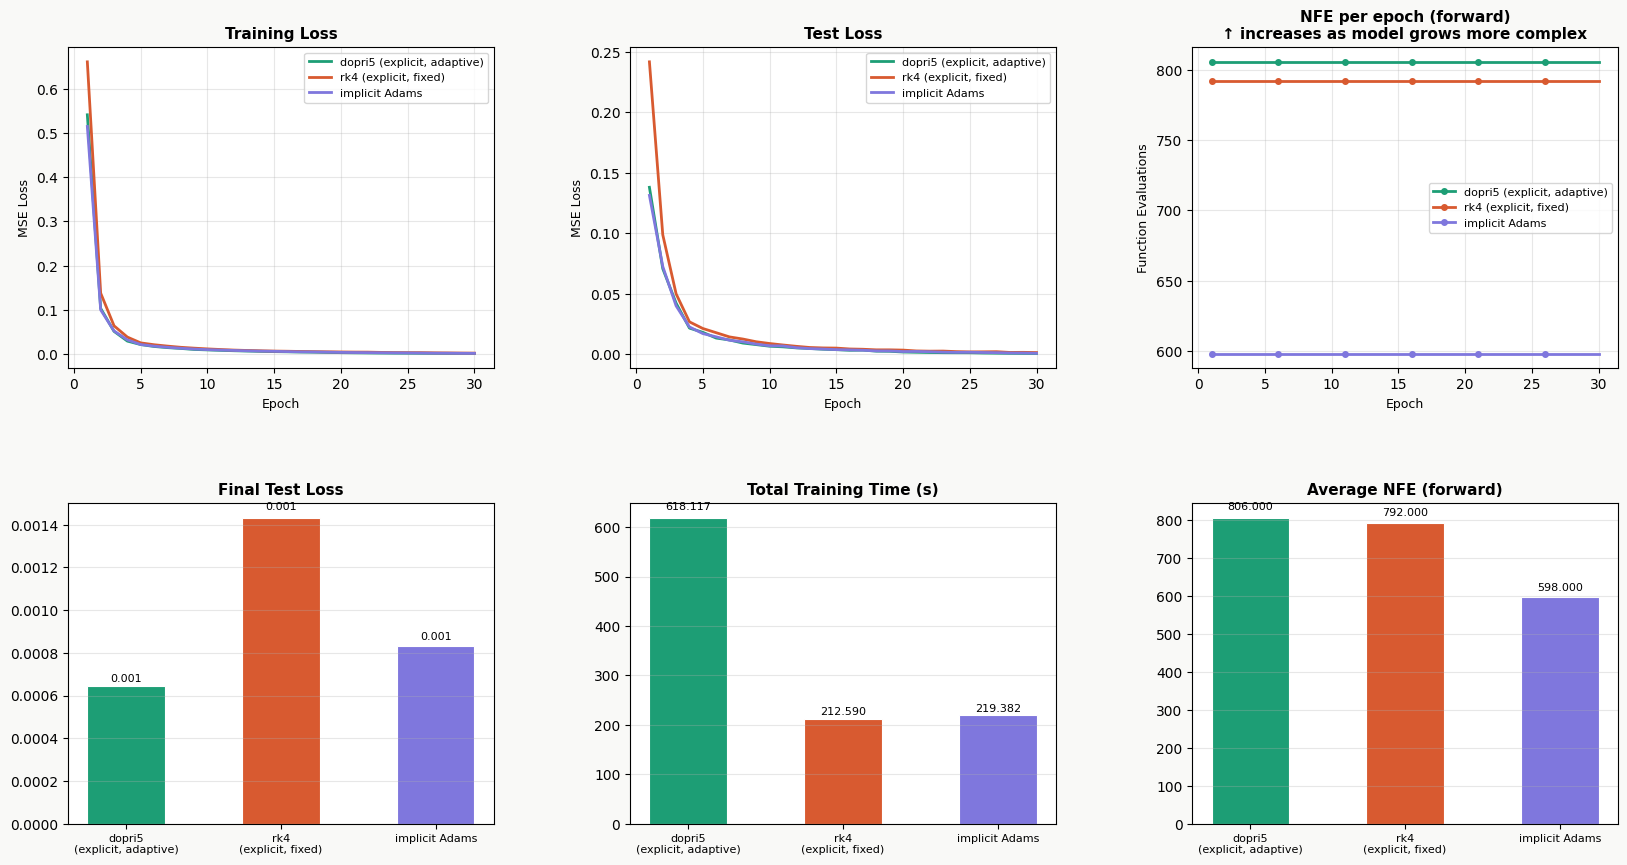

In [27]:
COLORS = {
    "dopri5"         : "#1D9E75",   # teal   — explicit adaptive
    "rk4"            : "#D85A30",   # orange — explicit fixed
    "implicit_adams" : "#7F77DD",   # purple — implicit
}
LABELS = {
    "dopri5"         : "dopri5 (explicit, adaptive)",
    "rk4"            : "rk4 (explicit, fixed)",
    "implicit_adams" : "implicit Adams",
}

epochs_axis = np.arange(1, N_EPOCHS + 1)

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#F9F9F7")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

ax_trloss = fig.add_subplot(gs[0, 0])
ax_teloss = fig.add_subplot(gs[0, 1])
ax_nfe    = fig.add_subplot(gs[0, 2])

for solver in all_models:
    h = all_histories[solver]
    c = COLORS[solver]
    lbl = LABELS[solver]
    ax_trloss.plot(epochs_axis, h["train_loss"],  color=c, lw=2, label=lbl)
    ax_teloss.plot(epochs_axis, h["test_loss"],   color=c, lw=2, label=lbl)
    ax_nfe.plot   (epochs_axis, h["nfe_forward"], color=c, lw=2,
                   marker="o", markevery=5, markersize=4, label=lbl)

for ax, title, ylabel in [
    (ax_trloss, "Training Loss",              "MSE Loss"),
    (ax_teloss, "Test Loss",                  "MSE Loss"),
    (ax_nfe,    "NFE per epoch (forward)\n"
                "↑ increases as model grows more complex",
                "Function Evaluations"),
]:
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("white")

solver_names  = list(all_models.keys())
bar_colors    = [COLORS[s] for s in solver_names]
x_pos         = np.arange(len(solver_names))
bar_w         = 0.5
tick_labels   = [LABELS[s].replace(" (", "\n(") for s in solver_names]

bar_data = [
    (gs[1, 0], "Final Test Loss",      [all_metrics[s]["final_test_loss"] for s in solver_names]),
    (gs[1, 1], "Total Training Time (s)",[all_metrics[s]["total_time_s"]  for s in solver_names]),
    (gs[1, 2], "Average NFE (forward)", [all_metrics[s]["avg_nfe"]        for s in solver_names]),
]

for gspec, title, values in bar_data:
    ax = fig.add_subplot(gspec)
    bars = ax.bar(x_pos, values, width=bar_w, color=bar_colors,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_facecolor("white")

plt.savefig("neural_ode_lorenz_results.png",
            dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("  Saved: neural_ode_lorenz_results.png")
plt.show()

### Long-term Prediction

  Saved: neural_ode_lorenz_longterm.png


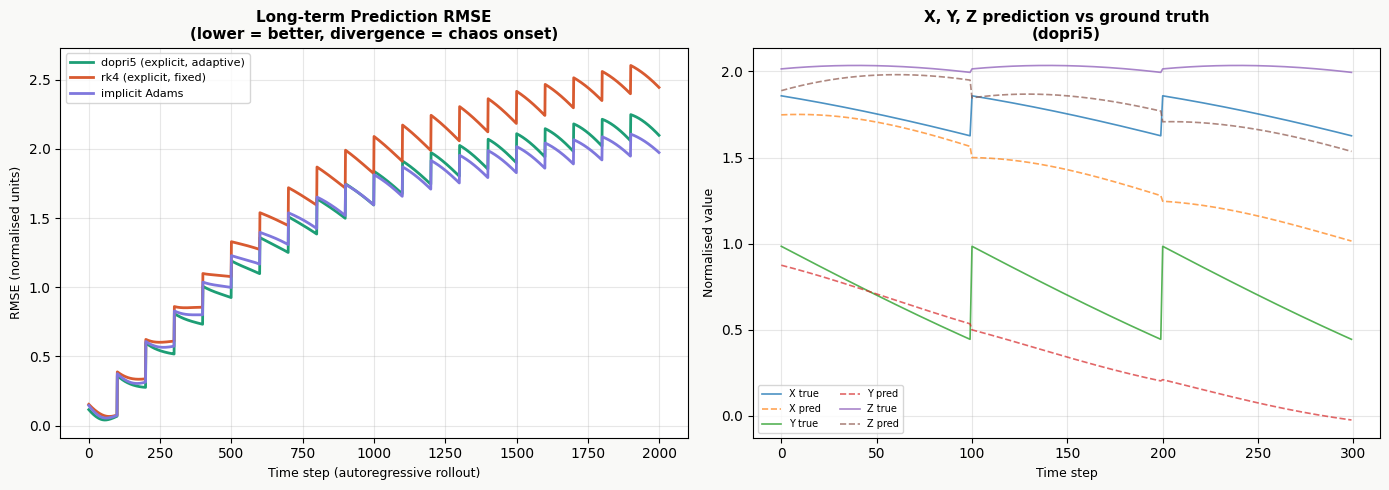

In [28]:
def long_term_rollout(model, start_traj, n_windows=20):

    model.eval()
    all_preds = []
    x0 = start_traj[0:1, 0, :].clone()

    with torch.no_grad():
        for _ in range(n_windows):
            pred = model(x0, t_span)
            all_preds.append(pred[0].cpu().numpy())
            x0 = pred[:, -1, :]

    pred_full  = np.concatenate(all_preds, axis=0)
    return pred_full


N_WINDOWS = 20
gt_long = np.concatenate([
    test_trajs[0, :, :].cpu().numpy()
    for _ in range(N_WINDOWS)
], axis=0)[:N_WINDOWS * TRAJ_LEN]

fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.patch.set_facecolor("#F9F9F7")

ax_rmse = axes[0]
ax_xyz  = axes[1]

for solver, model in all_models.items():
    pred_long = long_term_rollout(model, test_trajs[:1], N_WINDOWS)
    n_steps   = min(len(pred_long), len(gt_long))
    rmse      = np.sqrt(((pred_long[:n_steps] - gt_long[:n_steps]) ** 2)
                        .mean(axis=1))
    ts        = np.arange(n_steps)
    ax_rmse.plot(ts, rmse, color=COLORS[solver], lw=2, label=LABELS[solver])

ax_rmse.set_title("Long-term Prediction RMSE\n"
                  "(lower = better, divergence = chaos onset)",
                  fontsize=11, fontweight="bold")
ax_rmse.set_xlabel("Time step (autoregressive rollout)", fontsize=9)
ax_rmse.set_ylabel("RMSE (normalised units)", fontsize=9)
ax_rmse.legend(fontsize=8)
ax_rmse.grid(True, alpha=0.3)
ax_rmse.set_facecolor("white")

# X, Y, Z individual component prediction for dopri5 vs ground truth
best_solver = min(all_metrics, key=lambda s: all_metrics[s]["final_test_loss"])
pred_best   = long_term_rollout(all_models[best_solver], test_trajs[:1], N_WINDOWS)
n_plot      = min(len(pred_best), len(gt_long), 300)

for var_idx, var_name in enumerate(STATE_COLS):
    ax_xyz.plot(gt_long[:n_plot, var_idx],
                alpha=0.8, lw=1.2, label=f"{var_name} true")
    ax_xyz.plot(pred_best[:n_plot, var_idx],
                linestyle="--", alpha=0.7, lw=1.2,
                label=f"{var_name} pred")

ax_xyz.set_title(f"X, Y, Z prediction vs ground truth\n({best_solver})",
                 fontsize=11, fontweight="bold")
ax_xyz.set_xlabel("Time step", fontsize=9)
ax_xyz.set_ylabel("Normalised value", fontsize=9)
ax_xyz.legend(fontsize=7, ncol=2)
ax_xyz.grid(True, alpha=0.3)
ax_xyz.set_facecolor("white")

plt.tight_layout()
plt.savefig("neural_ode_lorenz_longterm.png",
            dpi=150, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
print("  Saved: neural_ode_lorenz_longterm.png")
plt.show()